# **U-Net 모델 구현**

✅ 아래 코드는 PyTorch로 작성한 간단한 U-Net 모델입니다.

✅ 주요 목표: 작은 이미지 세트로 segmentation 학습을 테스트하기!

✅ 특징: 업샘플링(deconv/upsample 선택 가능), 입력 스케일링, Gaussian noise 추가, 배치 정규화 적용

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# --- 작은 U-Net 정의 ---
class UNetSmall(nn.Module):
    def __init__(self, upsample_mode='deconv', net_scaling=None, edge_crop=0, gaussian_noise_std=0.1):
        super().__init__()
        self.net_scaling = net_scaling
        self.edge_crop = edge_crop
        self.gaussian_noise_std = gaussian_noise_std
        self.upsample_mode = upsample_mode

         # Convolution Block: Conv -> ReLU -> Conv -> ReLU
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        # 인코더 부분 목표 -> 128 까지!
        self.enc1 = conv_block(3, 16)
        self.enc2 = conv_block(16, 32)
        self.enc3 = conv_block(32, 64)
        self.enc4 = conv_block(64, 128)
        # Bottleneck
        self.center = conv_block(128, 128)
        self.pool = nn.MaxPool2d(2)


        # 업샘플링 부분 정의 (deconv 또는 upsample+conv) 로
        if upsample_mode == 'deconv':
            def upsample_layer(in_c, out_c):
                return nn.ConvTranspose2d(in_c, out_c, 2, stride=2)
        else:
            def upsample_layer(in_c, out_c):
                return nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    nn.Conv2d(in_c, out_c, 1)
                )
        # 디코더 부분
        self.up4 = upsample_layer(128, 64)
        self.dec4 = conv_block(192, 64)
        self.up3 = upsample_layer(64, 32)
        self.dec3 = conv_block(96, 32)
        self.up2 = upsample_layer(32, 16)
        self.dec2 = conv_block(48, 16)
        self.up1 = upsample_layer(16, 16)
        self.dec1 = conv_block(32, 16)

        # 최종 출력: 1채널(segmentation mask)
        self.final = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        if self.net_scaling:
        # 입력 스케일링
            x = F.avg_pool2d(x, self.net_scaling)
        # Gaussian noise 추가
        if self.gaussian_noise_std:
            noise = torch.randn_like(x) * self.gaussian_noise_std
            x = x + noise

        # 배치 정규화 적용
        x = F.batch_norm(x, running_mean=None, running_var=None, training=True)

        # 인코더
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        # Bottleneck
        center = self.center(self.pool(e4))

        # 디코더 + Skip Connection
        d4 = self.up4(center)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = torch.sigmoid(out)
         # Crop + Pad
        if self.edge_crop > 0:
            out = out[:, :, self.edge_crop:-self.edge_crop, self.edge_crop:-self.edge_crop]
            out = F.pad(out, (self.edge_crop, self.edge_crop, self.edge_crop, self.edge_crop))
        # Upsample 다시 확대
        if self.net_scaling:
            out = F.interpolate(out, scale_factor=self.net_scaling, mode='nearest')

        return out


## **학습용 데이터 생성하기**

In [6]:
batch_size = 32
x = torch.randn(batch_size, 3, 128, 128)  # RGB 이미지
y = (torch.rand(batch_size, 1, 128, 128) > 0.5).float()  # 랜덤 이진 마스크

dataset = TensorDataset(x, y)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

## **데이터 시각화**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.498047..4.0262094].


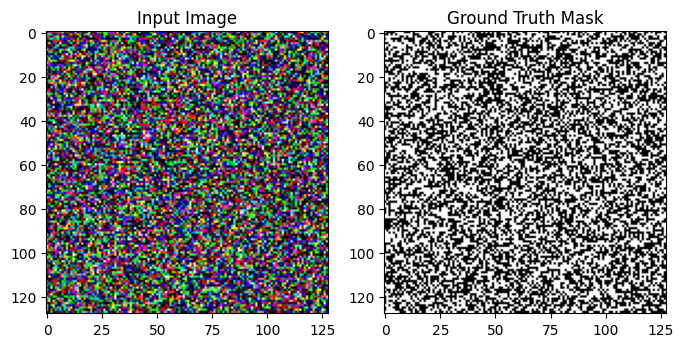

In [7]:
import matplotlib.pyplot as plt
# 첫 번째 이미지를 시각화
sample_x = x[0]
sample_y = y[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_x.permute(1, 2, 0).numpy())
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(sample_y.squeeze().numpy(), cmap='gray')
plt.title('Ground Truth Mask')
plt.show()

## **모델 선언 및 학습**

In [8]:
# --- 모델 선언 및 학습 ---
model = UNetSmall(upsample_mode='deconv', net_scaling=None, edge_crop=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# 간단히 30 epoch만
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.6937
Epoch 2, Loss: 0.6932
Epoch 3, Loss: 0.6932
Epoch 4, Loss: 0.6931
Epoch 5, Loss: 0.6931
Epoch 6, Loss: 0.6931
Epoch 7, Loss: 0.6930
Epoch 8, Loss: 0.6930
Epoch 9, Loss: 0.6929
Epoch 10, Loss: 0.6929


## **아래 주석을 풀고 U-Net 모델에 대해 간단히 설명해주세요 😀**

[답변]

---

U-Net은 이미지 semantic segmentation을 위한 CNN 구조로, 2015년 의료 이미지 분석을 위해 제안되었습니다.

핵심 구조는 인코더-디코더 + Skip Connection입니다:

- 인코더 (Contracting Path): Conv Block + MaxPooling으로 점진적으로 공간 해상도를 줄이면서 feature map을 추출합니다. 코드에서는 enc1(3→16) → enc2(16→32) → enc3(32→64) → enc4(64→128) 순으로 채널을 늘려가며 context(의미 정보)를 압축합니다.
- Bottleneck: 가장 압축된 표현(center, 128채널)을 생성합니다.
- 디코더 (Expanding Path): Upsample(deconv 또는 nearest+conv) + Conv Block으로 해상도를 복원합니다. 코드의 up4 → dec4 → up3 → dec3 → ... 흐름이 이에 해당합니다.
- Skip Connection: 인코더의 각 단계 feature map(e1~e4)을 디코더의 대응 레벨과 torch.cat으로 concatenate합니다. 이를 통해 인코더가 압축 과정에서 잃어버린 **공간적 디테일(위치 정보)**을 디코더에 다시 전달합니다.
- 최종 출력: 1채널 Conv + Sigmoid → 픽셀별 확률값으로 이진 segmentation mask를 생성합니다.

## **아래 주석을 풀고 DeepLabv1, v2, v3. v3+  모델에 대해 각각 간단히 설명해주세요 🐶**

[답변]


---

[DeepLab v1]

VGG 기반 CNN에 **Atrous Convolution(dilated convolution)**을 처음 도입한 버전입니다. 일반 Conv는 MaxPooling으로 해상도를 줄여 spatial 정보를 잃는데, Atrous Conv는 커널 사이에 간격(dilation rate)을 두어 해상도를 유지하면서 receptive field를 넓힐 수 있습니다. 또한 경계를 정밀하게 복원하기 위해 후처리로 **CRF(Conditional Random Field)**를 사용합니다.

[DeepLab v2]

v1에서 한 가지 dilation rate만 사용하던 것을 확장하여, **ASPP(Atrous Spatial Pyramid Pooling)**를 도입합니다. 서로 다른 dilation rate(e.g. 6, 12, 18, 24)의 Atrous Conv를 병렬로 적용해 다양한 스케일의 context 정보를 동시에 포착합니다. 백본을 ResNet으로 교체하여 성능을 높였습니다.

[DeepLab v3]

ASPP를 개선하여 Global Average Pooling 브랜치를 추가하고, Batch Normalization을 포함시킵니다. Dilation rate를 더 크게 키워도 성능이 유지되도록 설계를 정비했으며, CRF 후처리를 제거해도 경쟁력 있는 성능을 냅니다. 인코더만 있는 구조입니다.

[DeepLab v3+]

v3에 디코더 모듈을 추가한 인코더-디코더 구조입니다. 인코더로 v3의 ASPP 출력을 받고, 인코더 중간 레이어의 low-level feature와 합쳐(skip connection처럼) 경계를 더 정밀하게 복원합니다. 백본으로 Xception을 사용하고, Depthwise Separable Convolution을 도입해 연산 효율도 개선했습니다.